# Synthetic Spike-Train Dataset Visualisation

This notebook visualises the two synthetic spike-train datasets used in the project:

- **ISI** — inter-spike-interval dataset (`isi/isi_dataset.h5`), produced by `isi/isi_data_gen.py`.
- **CCISI** — cross-correlation ISI dataset (`ccisi/ccisi_dataset.h5`), produced by `ccisi/ccisi_data_gen.py`.

Both datasets share the same **(firing rate, ISI) feature space**. Section 4 combines, in a single figure, the feature-space scatter (with a straight LDA decision boundary) on the left and matched spike-train examples for each class on the right.

## 1. Common setup

Shared imports, styling constants, and helpers used throughout. The drawing helpers each render onto a supplied Axes so they can be composed into a single combined figure in section 4.

In [1]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Notebook lives in result_visualization/auxillary_plots/synthetic/; the datasets
# are read in place from exp_fixed_weight_perturbation/code/synthetic/.
CODE_SYNTHETIC_DIR = os.path.join("..", "..", "..", "code", "synthetic")

# Class styling shared across all plots (classic blue / red).
CLASS_COLORS = {0: "blue", 1: "red"}
CLASS_NAMES = {0: "Class 0", 1: "Class 1"}

# Colours cycling through CCISI neuron pairs in the raster plots.
PAIR_COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#a65628", "#f781bf", "#999999",
    "#66c2a5", "#fc8d62",
]

In [2]:
def load_dataset(path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Load the HDF5 dataset from *path*.

    Args:
        path: Path to the HDF5 file.

    Returns:
        Tuple of (spike_trains, labels, firing_rates, isis).
    """
    with h5py.File(path, "r") as hdf:
        spike_trains = hdf["X"][:]
        labels = hdf["Y"][:]
        firing_rates = hdf["firing_rates"][:]
        isis = hdf["isis"][:]
    return spike_trains, labels, firing_rates, isis

In [3]:
def gap_midline(
    firing_rates: np.ndarray,
    isis: np.ndarray,
    labels: np.ndarray,
) -> tuple[float, float]:
    """Fit a straight line through the middle of the gap between the two classes.

    For each distinct firing rate the gap midpoint is the mean of the highest
    class-1 ISI and the lowest class-0 ISI. A least-squares line is fit through
    those midpoints, so the boundary bisects the gap and follows its tilt.

    Args:
        firing_rates: 1-D array of firing rates (Hz).
        isis: 1-D array of ISI values (ms).
        labels: 1-D array of binary class labels.

    Returns:
        Tuple (slope, intercept) for the line ``isi = slope * firing_rate + intercept``.
    """
    unique_rates = np.unique(firing_rates)
    midpoints = []
    for rate in unique_rates:
        at_rate = firing_rates == rate
        class1_top = isis[at_rate & (labels == 1)].max()
        class0_bottom = isis[at_rate & (labels == 0)].min()
        midpoints.append(0.5 * (class1_top + class0_bottom))

    slope, intercept = np.polyfit(unique_rates, midpoints, 1)
    return slope, intercept

In [4]:
def draw_scatter(
    ax: plt.Axes,
    firing_rates: np.ndarray,
    isis: np.ndarray,
    labels: np.ndarray,
) -> None:
    """Draw the firing-rate vs. ISI scatter with the gap-bisecting boundary onto *ax*."""
    ax.set_axisbelow(True)  # grid behind the data points

    for class_id in (0, 1):
        mask = labels == class_id
        ax.scatter(
            firing_rates[mask], isis[mask],
            color=CLASS_COLORS[class_id],
            label=CLASS_NAMES[class_id],
            s=10,
        )

    # Straight decision boundary through the middle of the gap between the classes,
    # following the gap's tilt.
    slope, intercept = gap_midline(firing_rates, isis, labels)
    x_line = np.array([firing_rates.min(), firing_rates.max()])
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line,
        color="black", linewidth=2, label="Decision boundary",
    )

    ax.set_xlabel("Firing Rate (Hz)")
    ax.set_ylabel("ISI/CCISI (ms)")
    ax.set_title("Feature Space: Firing Rate vs. ISI/CCISI")
    ax.legend(loc="upper right")
    ax.grid(True)

In [5]:
def draw_isi_train(
    ax: plt.Axes,
    train: np.ndarray,
    class_id: int,
    title: str,
) -> None:
    """Draw a single ISI spike train (all neurons, one class colour) onto *ax*."""
    ax.set_axisbelow(True)
    num_neurons = train.shape[0]
    for neuron_idx in range(num_neurons):
        spike_times = np.where(train[neuron_idx] == 1)[0]
        ax.vlines(
            spike_times, neuron_idx + 0.5, neuron_idx + 1.5,
            color=CLASS_COLORS[class_id], linewidth=0.8,
        )
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Neuron")
    ax.set_yticks(range(1, num_neurons + 1))
    ax.set_ylim(0.5, num_neurons + 0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.4)

In [6]:
def draw_ccisi_train(
    ax: plt.Axes,
    train: np.ndarray,
    title: str,
) -> None:
    """Draw a single CCISI spike train (neuron pairs in matching colours) onto *ax*."""
    ax.set_axisbelow(True)
    num_neurons = train.shape[0]
    for pair_idx in range(num_neurons // 2):
        color = PAIR_COLORS[pair_idx % len(PAIR_COLORS)]
        for neuron_idx in (pair_idx * 2, pair_idx * 2 + 1):
            spike_times = np.where(train[neuron_idx] == 1)[0]
            ax.vlines(
                spike_times, neuron_idx + 0.5, neuron_idx + 1.5,
                color=color, linewidth=0.8,
            )
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Neuron")
    ax.set_yticks(range(1, num_neurons + 1))
    ax.set_yticklabels(
        [f"{'a' if i % 2 == 0 else 'b'}{i // 2}" for i in range(num_neurons)],
        fontsize=6,
    )
    ax.set_ylim(0.5, num_neurons + 0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.set_xlabel("Time (ms)")

In [7]:
def plot_overview(
    firing_rates: np.ndarray,
    isis: np.ndarray,
    labels: np.ndarray,
    isi_spike_trains: np.ndarray,
    ccisi_spike_trains: np.ndarray,
    sample_indices: list[int],
) -> None:
    """Combined overview: feature-space scatter (left) and matched examples (right).

    The left panel is the shared firing-rate vs. ISI scatter with the LDA decision
    boundary. The right panel is a 2x2 grid of matched spike-train examples: rows
    are the datasets (top: ISI, bottom: CCISI) and columns are the samples in
    ``sample_indices`` (one per class). Because ISI and CCISI share the same
    features element-wise, each column uses a single index and therefore shows the
    same firing rate and ISI/CCISI interval in both rows.

    Args:
        firing_rates: 1-D array of firing rates (Hz), shared by both datasets.
        isis: 1-D array of ISI values (ms), shared by both datasets.
        labels: 1-D array of binary class labels (shared by both datasets).
        isi_spike_trains: ISI array of shape (N, num_neurons, time_steps).
        ccisi_spike_trains: CCISI array of shape (N, num_neurons, time_steps).
        sample_indices: Sample indices to display, one per grid column.
    """
    num_cols = len(sample_indices)
    fig = plt.figure(figsize=(8 + 6 * num_cols, 8))
    grid = fig.add_gridspec(2, 1 + num_cols, width_ratios=[1.4] + [1] * num_cols)

    # Left: shared feature-space scatter, spanning both rows.
    ax_scatter = fig.add_subplot(grid[:, 0])
    draw_scatter(ax_scatter, firing_rates, isis, labels)

    # Right: one column per sample, ISI on top and CCISI on the bottom.
    reference_ax = None
    first_isi_ax = None
    for col, sample_idx in enumerate(sample_indices):
        class_id = int(labels[sample_idx])
        fr = firing_rates[sample_idx]
        isi = isis[sample_idx]
        label = f"{CLASS_NAMES[class_id]}, FR={fr:.1f} Hz, ISI={isi:.0f} ms"

        ax_isi = fig.add_subplot(grid[0, col + 1], sharex=reference_ax)
        reference_ax = reference_ax or ax_isi
        first_isi_ax = first_isi_ax or ax_isi
        ax_ccisi = fig.add_subplot(grid[1, col + 1], sharex=reference_ax)

        draw_isi_train(ax_isi, isi_spike_trains[sample_idx], class_id, f"ISI Raster \u2014 {label}")
        ax_isi.tick_params(labelbottom=False)  # time axis shown on the CCISI row
        draw_ccisi_train(ax_ccisi, ccisi_spike_trains[sample_idx], f"CCISI Raster \u2014 {label}")

    # Panel labels: a) feature space, b) the spike-train example grid.
    ax_scatter.text(
        -0.07, 1.02, "a)", transform=ax_scatter.transAxes,
        fontsize=15, fontweight="bold", va="bottom", ha="right",
    )
    first_isi_ax.text(
        -0.09, 1.05, "b)", transform=first_isi_ax.transAxes,
        fontsize=15, fontweight="bold", va="bottom", ha="right",
    )
    fig.tight_layout()
    plt.show()

## 2. ISI dataset

The ISI dataset encodes class information in the inter-spike interval of independent neurons (10 neurons per sample). Load it and summarise.

In [8]:
ISI_DATASET_PATH = os.path.join(CODE_SYNTHETIC_DIR, "isi", "isi_dataset.h5")

isi_spike_trains, isi_labels, isi_firing_rates, isi_isis = load_dataset(
    ISI_DATASET_PATH
)

print(
    f"Loaded dataset: {isi_spike_trains.shape[0]} samples, "
    f"{isi_spike_trains.shape[1]} neurons, {isi_spike_trains.shape[2]} time steps"
)
print(f"  Class 0: {(isi_labels == 0).sum()} samples")
print(f"  Class 1: {(isi_labels == 1).sum()} samples")

Loaded dataset: 3598 samples, 10 neurons, 1000 time steps
  Class 0: 1766 samples
  Class 1: 1832 samples


## 3. CCISI dataset

The CCISI dataset encodes class information in the cross-neuron ISI delay within **neuron pairs** `(a, b)` (20 neurons = 10 pairs per sample). It shares the same `firing_rates` and `isis` arrays as ISI, element-wise. Load it and summarise.

In [9]:
CCISI_DATASET_PATH = os.path.join(CODE_SYNTHETIC_DIR, "ccisi", "ccisi_dataset.h5")

ccisi_spike_trains, ccisi_labels, ccisi_firing_rates, ccisi_isis = load_dataset(
    CCISI_DATASET_PATH
)

print(
    f"Loaded dataset: {ccisi_spike_trains.shape[0]} samples, "
    f"{ccisi_spike_trains.shape[1]} neurons ({ccisi_spike_trains.shape[1] // 2} pairs), "
    f"{ccisi_spike_trains.shape[2]} time steps"
)
print(f"  Class 0: {(ccisi_labels == 0).sum()} samples")
print(f"  Class 1: {(ccisi_labels == 1).sum()} samples")

Loaded dataset: 3598 samples, 20 neurons (10 pairs), 1000 time steps
  Class 0: 1766 samples
  Class 1: 1832 samples


## 4. Combined overview

A single figure with the shared feature-space scatter (with LDA decision boundary) on the **left**, and a 2x2 grid of matched spike-train examples on the **right** — rows are the datasets (top: ISI, bottom: CCISI) and columns are the classes (left: class 0, right: class 1). Within each column both rows use the same sample index, so the firing rate and ISI/CCISI interval match between ISI and CCISI. Change the indices to inspect other samples.

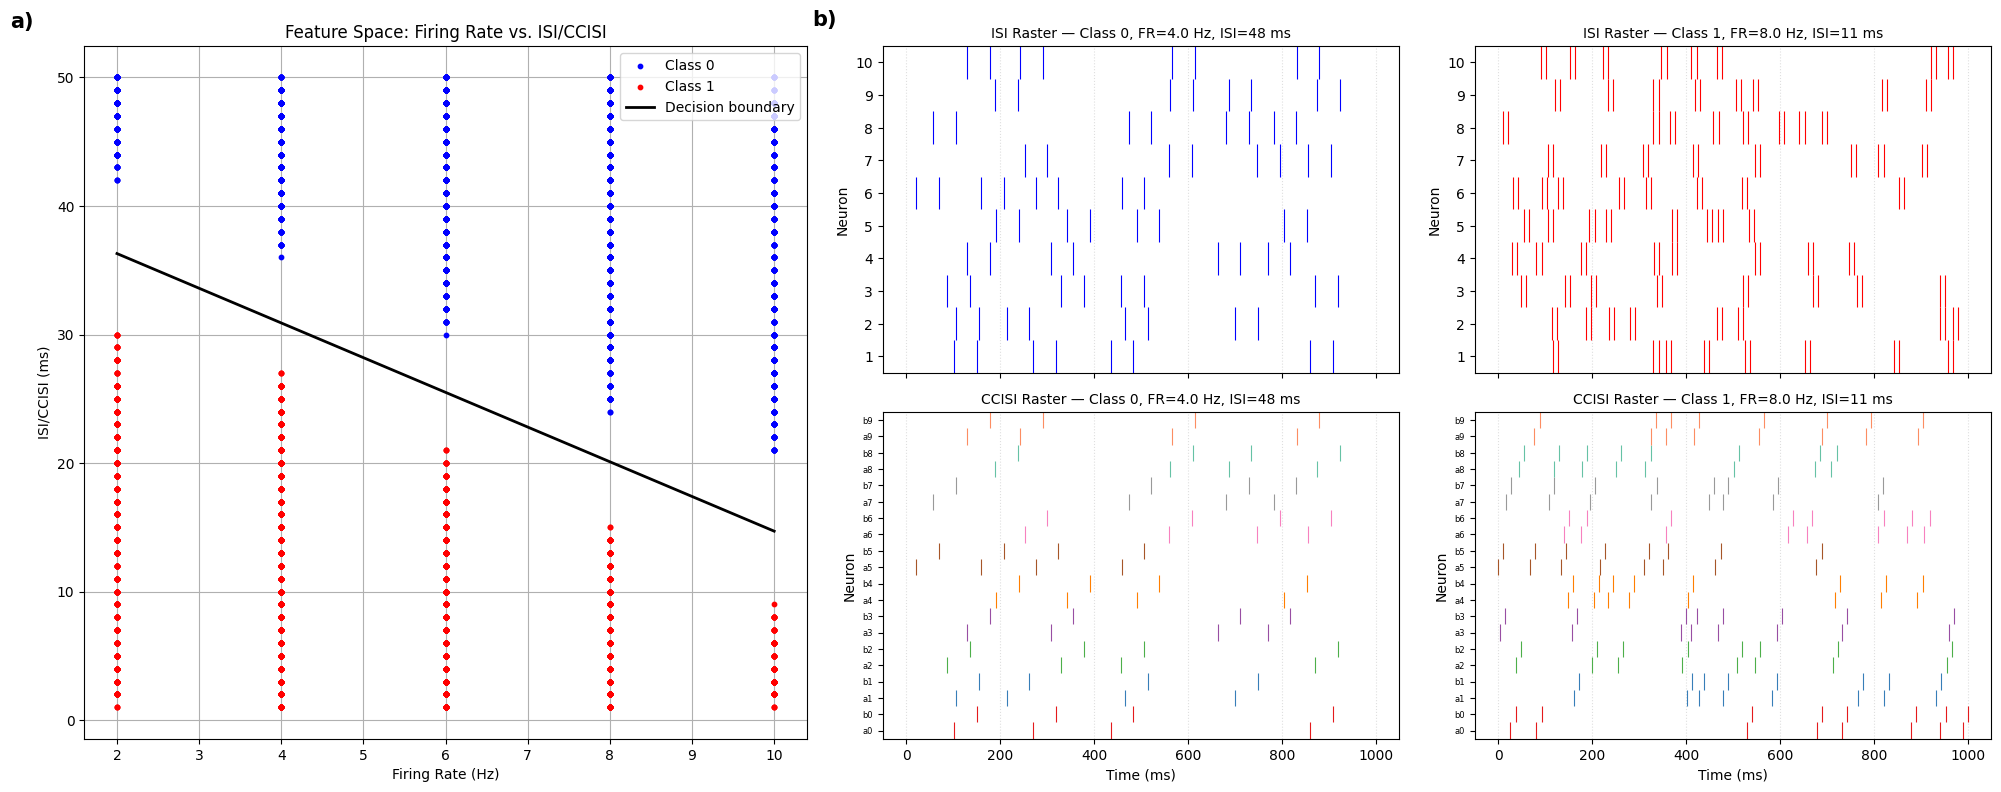

In [10]:
EXAMPLE_IDX_CLASS0 = 0   # Class 0 sample: FR = 4 Hz, ISI = 48 ms
EXAMPLE_IDX_CLASS1 = 26  # Class 1 sample: FR = 8 Hz, ISI = 11 ms

plot_overview(
    isi_firing_rates,
    isi_isis,
    isi_labels,
    isi_spike_trains,
    ccisi_spike_trains,
    sample_indices=[EXAMPLE_IDX_CLASS0, EXAMPLE_IDX_CLASS1],
)